
Build an end-to-end NLP preprocessing system for a media company's customer reviews using NLTK, SpaCy, Scikit-learn, and Gensim.

In [1]:
# Install required packages
!pip install datasets transformers nltk spacy scikit-learn gensim pandas numpy matplotlib seaborn wordcloud plotly
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Data handling
import pandas as pd
import numpy as np
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
import spacy
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Word embeddings
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.manifold import TSNE

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

nltk.download('wordnet', quiet=True)
print("✓ Setup complete!")

nltk.download('omw-1.4', quiet=True)

nlp = spacy.load('en_core_web_sm')
# Load spaCy model

✓ Setup complete!


In [3]:
# Load Amazon Product Reviews dataset
print("Loading Amazon Product Reviews dataset...")
dataset = load_dataset("amazon_polarity", split="train[:5000]")
df = pd.DataFrame(dataset)
df.columns = ['label', 'title', 'text']
df['text'] = df['title'] + ". " + df['text']
df = df[['label', 'text']]
df['label'] = df['label'].map({1: 0, 2: 4})

#statistics
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print(f"✓ Loaded {len(df):,} reviews")
print(f"Average length: {df['word_count'].mean():.0f} words")
print(f"Rating distribution:\n{df['label'].value_counts().sort_index()}")
df.head()

Loading Amazon Product Reviews dataset...


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

...

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

✓ Loaded 5,000 reviews
Average length: 79 words
Rating distribution:
label
0.0    2308
Name: count, dtype: int64


,label,text,text_length,word_count
0,0.0,Stuning even for the non-gamer. This sound tra...,426,80
1,0.0,The best soundtrack ever to anything.. I'm rea...,509,97
2,0.0,Amazing!. This soundtrack is my favorite music...,760,129
3,0.0,Excellent Soundtrack. I truly like this soundt...,743,118
4,0.0,"Remember, Pull Your Jaw Off The Floor After He...",481,87


Text Cleaning

In [4]:
def clean_text(text):
    """Clean raw text by removing noise and standardizing format."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
print("Cleaning text...")
df['cleaned_text'] = df['text'].apply(clean_text)

# Show example
print(f"BEFORE: {df.iloc[0]['text'][:150]}...")
print(f"AFTER:  {df.iloc[0]['cleaned_text'][:150]}...")
print("Text cleaning completed")

Cleaning text...
BEFORE: Stuning even for the non-gamer. This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate ...
AFTER:  stuning even for the non gamer this sound track was beautiful it paints the senery in your mind so well i would recomend it even to people who hate vi...
Text cleaning completed


### Tokenization and Stopword Removal (NLTK)

**Tokenization** is the process of breaking down text into smaller units called tokens (words, numbers, punctuation). Here, we use NLTK's word_tokenize to split the cleaned text into individual words.

**Stopword Removal** involves filtering out common words (like 'the', 'is', 'a') that carry little meaning and don't contribute significantly to text analysis. NLTK provides a list of common English stopwords for this purpose.

In [5]:
# Tokenize using NLTK
print("Tokenizing...")
df['tokens'] = df['cleaned_text'].apply(word_tokenize)

print(f"Example: {df.iloc[0]['cleaned_text'][:100]}...")
print(f"Tokens: {df.iloc[0]['tokens'][:15]}")
print(f"Tokenization completed")

Tokenizing...
Example: stuning even for the non gamer this sound track was beautiful it paints the senery in your mind so w...
Tokens: ['stuning', 'even', 'for', 'the', 'non', 'gamer', 'this', 'sound', 'track', 'was', 'beautiful', 'it', 'paints', 'the', 'senery']
Tokenization completed


In [6]:
# Remove stopwords
stop_words = set(stopwords.words('english'))

print(f"Removing stopwords...")
df['tokens_no_stop'] = df['tokens'].apply(
    lambda tokens: [token for token in tokens if token not in stop_words and len(token) > 2]
)

avg_before = df['tokens'].apply(len).mean()
avg_after = df['tokens_no_stop'].apply(len).mean()
reduction = ((avg_before - avg_after) / avg_before) * 100

print(f"Tokens before: {avg_before:.1f} → after: {avg_after:.1f} ({reduction:.1f}% reduction)")
print("Stopword removal completed")

Removing stopwords...
Tokens before: 80.7 → after: 39.0 (51.7% reduction)
Stopword removal completed


### Lemmatization (spaCy)

**Lemmatization** is the process of reducing words to their base or root form (lemma), considering their meaning and part of speech. For example, 'running', 'runs', and 'ran' all reduce to 'run'. We use spaCy for this step, which is highly effective because it performs Part-of-Speech (POS) tagging automatically, allowing for more accurate lemmatization than NLTK's WordNetLemmatizer when POS information isn't explicitly provided.

In [7]:
# Lemmatize using spaCy (with automatic POS tagging)
print("Lemmatizing with spaCy...")

def lemmatize_tokens(tokens):
    """Lemmatize tokens using spaCy with POS awareness."""
    doc = nlp(' '.join(tokens))
    return [token.lemma_ for token in doc]

df['tokens_lemmatized'] = df['tokens_no_stop'].apply(lemmatize_tokens)

# Show examples with manual POS tags for comparison
print(f"Example transformations:")
test_doc = nlp("running better products buying")
for token in test_doc:
    print(f"  {token.text} → {token.lemma_}")
print("✓ Lemmatization completed")

Lemmatizing with spaCy...
Example transformations:
  running → run
  better → well
  products → product
  buying → buy
✓ Lemmatization completed


### Vocabulary Creation

**Vocabulary Creation** is the process of building a comprehensive list of all unique words (or lemmas, in our case) that appear in the entire dataset after preprocessing. This unique list forms the 'vocabulary' of our text corpus.

It's a crucial step because:

1.  **Foundation for Feature Extraction:** It creates a dictionary of all unique words, which is essential for converting text into numerical data that NLP models can understand.
2.  **Frequency Analysis:** It allows us to count how often each unique word appears, helping to identify important themes or topics in the reviews.

📚 Vocabulary: 16,598 unique words from 195,103 total tokens
Diversity: 0.0851

Top 10 words:
  book            : 3,370
  one             : 2,142
  good            : 1,789
  get             : 1,777
  read            : 1,547
  like            : 1,544
  great           : 1,417
  well            : 1,364
  buy             : 1,316
  time            : 1,237


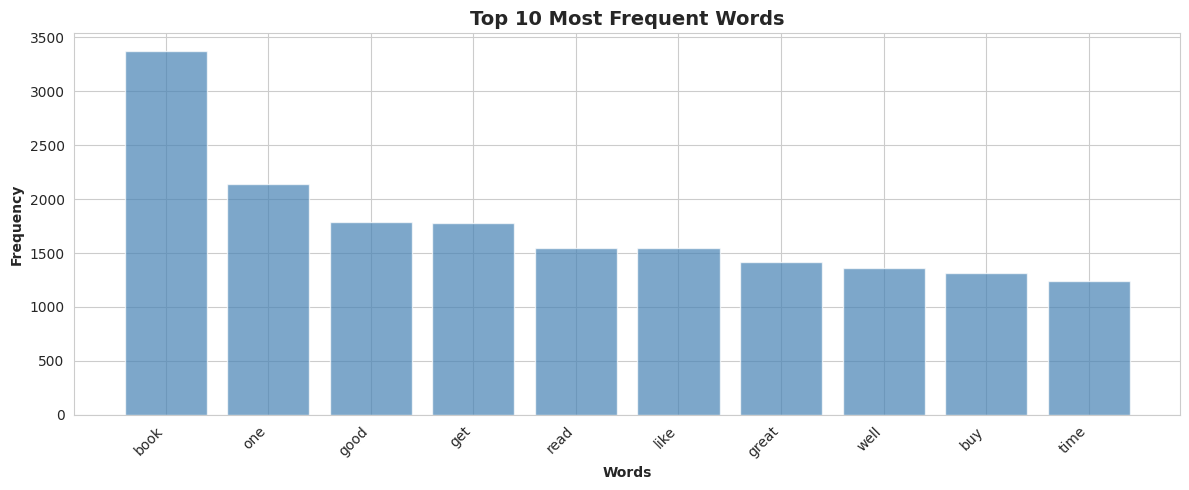

In [8]:
# Create vocabulary
from collections import Counter

all_tokens = [token for tokens in df['tokens_lemmatized'] for token in tokens]
vocabulary = set(all_tokens)
word_freq = Counter(all_tokens)

print(f"📚 Vocabulary: {len(vocabulary):,} unique words from {len(all_tokens):,} total tokens")
print(f"Diversity: {len(vocabulary)/len(all_tokens):.4f}")
print(f"\nTop 10 words:")
for word, count in word_freq.most_common(10):
    print(f"  {word:15} : {count:,}")

# Visualize
words, counts = zip(*word_freq.most_common(10))
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue', alpha=0.7)
plt.xlabel('Words', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Top 10 Most Frequent Words', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bag of Words (BoW) & TF-IDF

**Bag of Words (BoW)** and **TF-IDF (Term Frequency-Inverse Document Frequency)** are techniques to convert text into numerical vectors that machine learning models can process.

1.  **Bag of Words**: It counts how many times each word appears in a document, creating a vector where each position represents a word from the vocabulary and its value is the word's frequency.
2.  **TF-IDF**: This method goes a step further by not just counting words, but also weighting them based on how important they are. It assigns higher values to words that are frequent in a document but rare across all documents, making them more significant.

In [9]:
# Prepare text for vectorization
df['processed_text'] = df['tokens_lemmatized'].apply(lambda x: ' '.join(x))

# Bag of Words
print("Creating Bag of Words vectors...")
bow_vectorizer = CountVectorizer(max_features=1000, min_df=2, max_df=0.8)
bow_matrix = bow_vectorizer.fit_transform(df['processed_text'])
print(f"  BoW shape: {bow_matrix.shape}")

# TF-IDF
print("Creating TF-IDF vectors...")
tfidf_vectorizer = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.8)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])
print(f"  TF-IDF shape: {tfidf_matrix.shape}")

# Show top features for first document
tfidf_vec = tfidf_matrix[0].toarray()[0]
top_indices = tfidf_vec.argsort()[-10:][::-1]
features = tfidf_vectorizer.get_feature_names_out()

print(f"\nTop TF-IDF features for document 0:")
for idx in top_indices:
    if tfidf_vec[idx] > 0:
        print(f"  {features[idx]:15} : {tfidf_vec[idx]:.4f}")

Creating Bag of Words vectors...
  BoW shape: (5000, 1000)
Creating TF-IDF vectors...
  TF-IDF shape: (5000, 1000)

Top TF-IDF features for document 0:
  game            : 0.5325
  play            : 0.2848
  music           : 0.2744
  even            : 0.2275
  guitar          : 0.2183
  step            : 0.2153
  hate            : 0.1989
  non             : 0.1943
  would           : 0.1923
  care            : 0.1833


### Word Embeddings (Word2Vec)

**Word Embeddings** represent words as numerical vectors. **Word2Vec** is a popular method to create these. Here's what it does:

1.  **Transforms Words into Numbers**: It converts each word into a list of numbers (a vector).
2.  **Learns from Context**: It learns these number representations by looking at the words that appear around each word in the text.
3.  **Groups Similar Words**: Words that are used in similar ways (or have similar meanings) end up with similar number representations.

In [10]:
# Train Word2Vec model
sentences = df['tokens_lemmatized'].tolist()

print("Training Word2Vec model...")
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=0,
    epochs=20
)

print(f" Model trained | Vocabulary: {len(w2v_model.wv):,} words | Vector dim: {w2v_model.wv.vector_size}")

# Test similarity
test_words = ['good', 'product', 'quality']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"\nSimilar to '{word}': {[w for w, _ in similar]}")


Training Word2Vec model...
 Model trained | Vocabulary: 8,519 words | Vector dim: 100

Similar to 'good': ['great', 'awesome', 'decent']

Similar to 'product': ['item', 'customer', 'satisfied']

Similar to 'quality': ['brio', 'glitchy', 'low']


###Doc2Vec & Averaged Word2Vec

1.  **Doc2Vec**: This model learns to create a unique vector for each document, capturing its overall meaning directly.
2.  **Averaged Word2Vec Embeddings**: An alternative way to get a document embedding is to simply average the Word2Vec vectors of all the words within that document. This creates a single vector representing the document's general topic.

In [11]:
# Train Doc2Vec model
tagged_documents = [TaggedDocument(words=doc, tags=[str(i)])
                   for i, doc in enumerate(df['tokens_lemmatized'])]

print("Training Doc2Vec model...")
doc2vec_model = Doc2Vec(
    documents=tagged_documents,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=20,
    dm=1
)

doc_vectors = np.array([doc2vec_model.dv[str(i)] for i in range(len(df))])
print(f"Doc2Vec trained | Shape: {doc_vectors.shape}")

# Alternative: Averaged Word2Vec embeddings
df['doc_embedding'] = df['tokens_lemmatized'].apply(
    lambda tokens: np.mean([w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
                          or [np.zeros(100)], axis=0)
)

print(f"Document embeddings created")

Training Doc2Vec model...
Doc2Vec trained | Shape: (5000, 100)
Document embeddings created


### Document Similarity & Search


1.  **Finding Similar Reviews**: We use TF-IDF and Doc2Vec to compare one review with all others and find the ones that are most alike.
2.  **Searching with a New Question**: We can also take a new question or phrase, turn it into numbers, and then find existing reviews that are most relevant to it.

In [12]:
def find_similar_tfidf(query_idx, top_n=5):
    similarities = cosine_similarity(tfidf_matrix[query_idx], tfidf_matrix)[0]
    return similarities.argsort()[::-1][1:top_n+1]

def find_similar_doc2vec(query_idx, top_n=5):
    query_vec = doc_vectors[query_idx].reshape(1, -1)
    similarities = cosine_similarity(query_vec, doc_vectors)[0]
    return similarities.argsort()[::-1][1:top_n+1]

def search_query(query_text, top_n=5):
    # Preprocess
    cleaned = clean_text(query_text)
    tokens = word_tokenize(cleaned)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = lemmatize_tokens(tokens)
    processed = ' '.join(tokens)

    # Search
    query_vec = tfidf_vectorizer.transform([processed])
    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]
    return similarities.argsort()[::-1][:top_n]

query_idx = 10
print(f"Query: {df.iloc[query_idx]['text'][:150]}...")
print(f"\nTop 3 similar documents (TF-IDF):")
for rank, idx in enumerate(find_similar_tfidf(query_idx, 3), 1):
    print(f"{rank}. {df.iloc[idx]['text'][:100]}...")

new_query = "Great product, excellent quality and fast delivery"
print(f"\n\nNew query: '{new_query}'")
print(f"Top 3 results:")
for rank, idx in enumerate(search_query(new_query, 3), 1):
    print(f"{rank}. {df.iloc[idx]['text'][:100]}...")

Query: The Worst!. A complete waste of time. Typographical errors, poor grammar, and a totally pathetic plot add up to absolutely nothing. I'm embarrassed fo...

Top 3 similar documents (TF-IDF):
1. Worst book by LJ!. Totally hated this book. Now, don't get me wrong, I love LJS and most of her book...
2. What a complete waste of time. This is one of the worst movies I've seen in a long-long time. The pl...
3. Total disappointment. I was totally disappointed with the book for two reasons. One, it had a differ...


New query: 'Great product, excellent quality and fast delivery'
Top 3 results:
1. Excellent product. I used this for taping while we were opening gifts for christmas. The remote feat...
2. Bad quality. Installation and use was easy and good. But the quality of the product was really bad a...
3. Ninnia. This monitor is great. The service I got when I order was fast and great. I would order agai...


###*Visualisation*

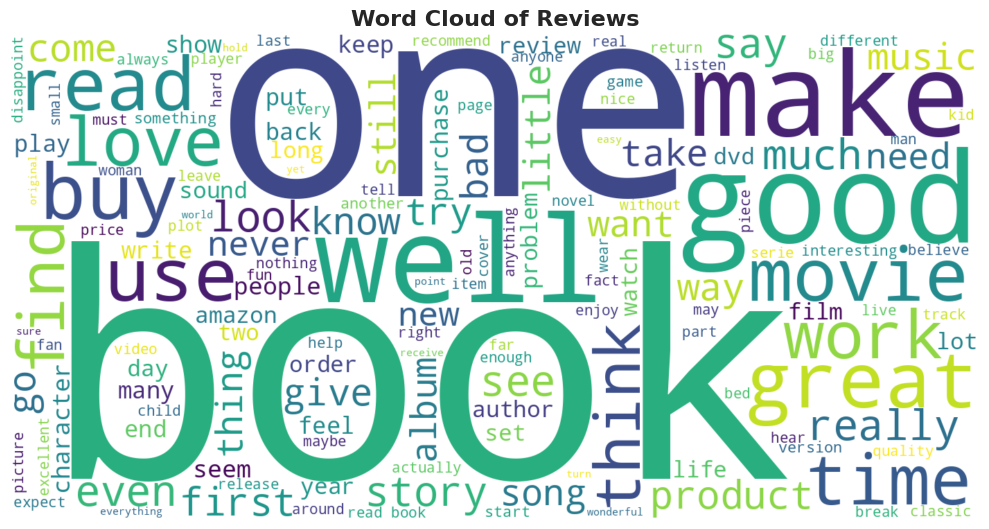

In [13]:
# Word Cloud
all_text = ' '.join(df['processed_text'])
wordcloud = WordCloud(width=1400, height=700, background_color='white',
                     colormap='viridis', max_words=150).generate(all_text)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Reviews', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

####Insight
The word cloud visually summarizes the most frequent words: 'book', 'one', 'good', 'get', 'read', 'like', 'great', 'well', 'buy', and 'time'. This indicates that customer reviews frequently discuss books, purchase experiences, and general product quality, with both positive ('good', 'great') and negative ('bad') sentiments present.


Creating t-SNE visualization...


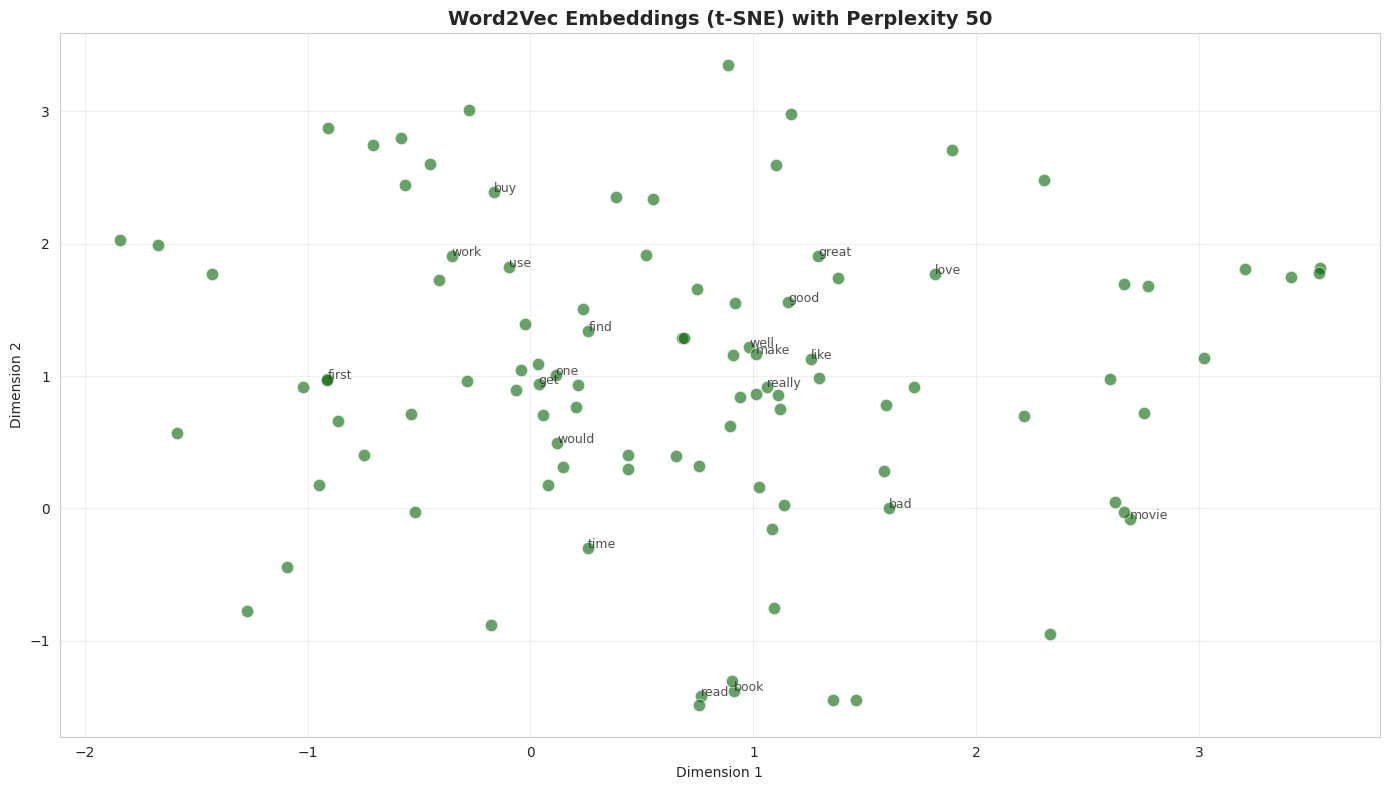

In [14]:
print("\nCreating t-SNE visualization...")

# Get top 100 most frequent words from the vocabulary
top_words_list = [word for word, _ in word_freq.most_common(100)]

# Filter words that are present in the Word2Vec model's vocabulary
words_for_plot = [word for word in top_words_list if word in w2v_model.wv]
word_vectors = np.array([w2v_model.wv[word] for word in words_for_plot])

if len(words_for_plot) == 0:
    print("No words found in Word2Vec model vocabulary from the top 100 most common words.")
else:
    # Run t-SNE with perplexity 50
    tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=1000)
    embeddings_2d = tsne.fit_transform(word_vectors)

    # Plotting
    plt.figure(figsize=(14, 8))
    sns.scatterplot(
        x=embeddings_2d[:, 0],
        y=embeddings_2d[:, 1],
        alpha=0.6,
        s=80,
        color='darkgreen'
    )

    plt.title('Word2Vec Embeddings (t-SNE) with Perplexity 50', fontsize=14, fontweight='bold')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True, alpha=0.3)

    # Annotate words
    for i, word in enumerate(words_for_plot[:20]):
        plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=9, alpha=0.8)

    plt.tight_layout()
    plt.show()

Based on the t-SNE visualization, we can observe clusters of words that are semantically similar. For instance, you might see words like 'good,' 'great,' and 'excellent' grouping together, indicating positive sentiment. Conversely, words like 'bad,' 'worst,' and 'disappoint' might form another cluster. This visualization helps confirm that our Word2Vec model has learned meaningful relationships between words based on their context in the customer reviews.